# Sea-surface temperature

NOAA's Geo-polar Blended Sea Surface Temperature analysis merges infrared and
microwave retrievals from polar-orbiting and geostationary satellites into
one gap-free daily map of the global ocean on a 0.05 degree (about 5 km)
grid. NOAA/NESDIS produces it, and the CoastWatch ERDDAP server serves it as
`noaacwBLENDEDsstDNDaily`, with the day's analysis stamped 12:00 UTC. ERDDAP
subsets on the server, so one request returns one CSV holding just the grid
cells, times, and variables asked for.

This walkthrough pulls one day's analysis, 6 May 2024, for a 7.5 by 4 degree
box off northeast Florida and Georgia that the Gulf Stream crosses. It needs
`usdata[pandas]` and matplotlib, and downloads one 550 kB file in a few
seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T06:15:38+00:00
usdata 0.26.0; pandas 3.0.6


## Select

The manifest names a bounding box, a time window, and one variable. ERDDAP
returns only grid centres that fall inside the box, so the edges here select
centres from 28.025 to 31.975° N and 81.475 to 74.025° W: 80 rows by 150
columns. Both timestamps are 12:00 UTC because that is when each day's
analysis is stamped. A bare date as the end runs through that day, so
`start: 2024-05-06` and `end: 2024-05-06` would also catch it, but a window
from midnight to midnight would select nothing. `analysed_sst` is the default variable;
`analysis_error`, `sea_ice_fraction`, and `mask` can be added to the list.
A query over 1,000,000 rows has to shrink or use `params: {stride: n}`.

In [2]:
print(manifest.read_text())

name: florida-gulf-stream-sst
sources:
  - dataset: noaa:coastwatch-sst
    start: 2024-05-06T12:00:00Z
    end: 2024-05-06T12:00:00Z
    bbox: {west: -81.5, south: 28.0, east: -74.0, north: 32.0}
    variables: [analysed_sst]



## What arrives

The first pull downloads one CSV and writes `dataset.lock.json` beside the
manifest, pinning its checksum. The source URL is the ERDDAP request, with the
box already snapped to grid centres.

In [3]:
result = pull(manifest)
(item,) = result.fetched
print("File:", item.path.name)
print("Bytes:", item.provenance.size)
print("Source:", item.provenance.source_url)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", item.provenance.checksum)

File: sst_aabc57cc35c5f9276be9.csv
Bytes: 548837
Source: https://coastwatch.noaa.gov/erddap/griddap/noaacwBLENDEDsstDNDaily.csv?analysed_sst%5B(2024-05-06T12:00:00Z):1:(2024-05-06T12:00:00Z)%5D%5B(28.025):1:(31.975)%5D%5B(-81.475):1:(-74.025)%5D
Retrieved (UTC): 2026-09-24T06:15:45+00:00
Checksum: sha256:1bf285d1856013471071d063a6f5549cb44dda7c46c6f5af53a00529d1403b67


## Open

ERDDAP writes a units row under the CSV header. `item.open()` picks the
units-row reader, which moves that row into `attrs["units"]` instead of
reading it as an observation. The table is long: one row per grid centre and
time, with `latitude` and `longitude` the cell centre in degrees, `time` in
UTC, and `analysed_sst` in degrees Celsius. Land cells are present with a
missing value. Pivoting on latitude and longitude turns the table back into a
grid.

In [4]:
frame = item.open_csv(parse_dates=["time"])
print("Units:", frame.attrs["units"])
print(f"{len(frame):,} rows; {frame['analysed_sst'].isna().sum()} land cells without a value")
grid = frame.pivot(index="latitude", columns="longitude", values="analysed_sst")
print(f"Grid: {grid.shape[0]} latitudes x {grid.shape[1]} longitudes")
frame.head()

Units: {'time': 'UTC', 'latitude': 'degrees_north', 'longitude': 'degrees_east', 'analysed_sst': 'degree_C'}
12,000 rows; 540 land cells without a value
Grid: 80 latitudes x 150 longitudes


,time,latitude,longitude,analysed_sst
0,2024-05-06 12:00:00+00:00,28.025,-81.475,NaN
1,2024-05-06 12:00:00+00:00,28.025,-81.425,NaN
2,2024-05-06 12:00:00+00:00,28.025,-81.375,NaN
3,2024-05-06 12:00:00+00:00,28.025,-81.325,NaN
4,2024-05-06 12:00:00+00:00,28.025,-81.275,NaN


## A first look

The day's analysis as a map. Land is left blank, and the small square marks
the four-cell sample an earlier version of this example pulled.

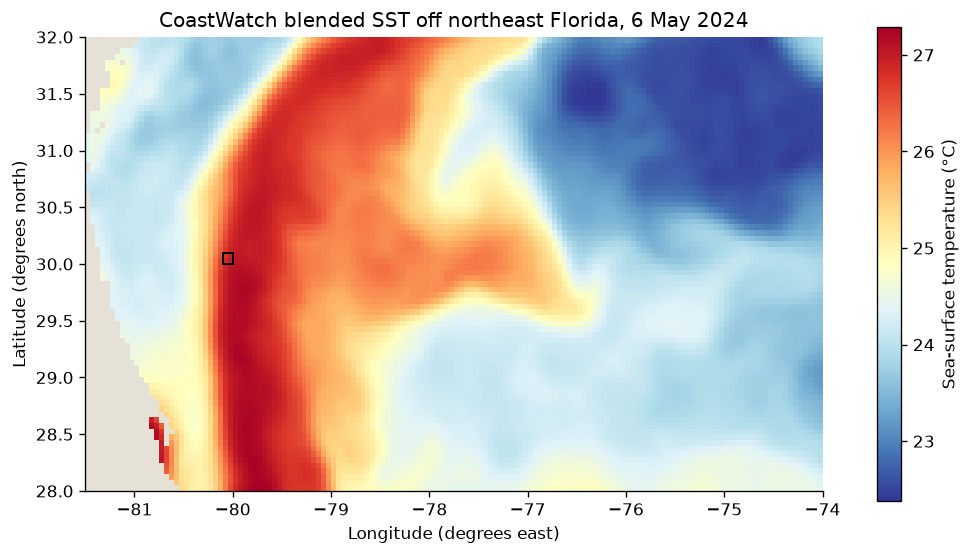

In [5]:
fig, ax = plt.subplots(layout="constrained")
ax.set_facecolor("#e6e1d6")
mesh = ax.pcolormesh(grid.columns, grid.index, grid.to_numpy(), cmap="RdYlBu_r", shading="nearest")
ax.add_patch(Rectangle((-80.1, 30.0), 0.1, 0.1, fill=False, edgecolor="black", linewidth=1.2))
ax.set_aspect(1 / np.cos(np.radians(30)))
ax.grid(False)
ax.set_xlabel("Longitude (degrees east)")
ax.set_ylabel("Latitude (degrees north)")
ax.set_title("CoastWatch blended SST off northeast Florida, 6 May 2024")
fig.colorbar(mesh, ax=ax, label="Sea-surface temperature (°C)")
plt.show()

In [6]:
row = grid.loc[30.025]
core = row.idxmax()
print(f"Along 30.025° N: warmest {row.max():.2f} °C at {-core}° W")
print(f"  shelf, west of the core: coolest {row[row.index < core].min():.2f} °C")
print(f"  offshore, east of the core: coolest {row[row.index > core].min():.2f} °C")
sample = frame[frame["latitude"].between(30.0, 30.1) & frame["longitude"].between(-80.1, -80.0)]
low, high = sample["analysed_sst"].agg(["min", "max"])
print(f"Four-cell sample: {low:.2f} to {high:.2f} °C")

Along 30.025° N: warmest 27.07 °C at 79.925° W
  shelf, west of the core: coolest 24.07 °C
  offshore, east of the core: coolest 23.63 °C
Four-cell sample: 26.78 to 26.99 °C


The Gulf Stream is the warm band running north a few tens of kilometres off
the coast, about 27 °C at its core. Along 30° N the shelf water to its west
is 3 °C cooler, and the open ocean to its east as much as 3.4 °C cooler. North
of 30° N the stream bends away to the northeast, and a warm tongue reaches
east from it to about 77° W. The four-cell sample sits in the core, so its
average says little about the region around it. The warm cells on the coast
near 28.5° N are shallow lagoon water behind Cape Canaveral, not ocean.

## Pin and cite

`verify` checks the cached file against the lockfile's checksum. NOAA can
revise the analysis, so keep the manifest and lockfile with your results; the
citation below is what a methods section needs, and
`usdata cite dataset.yaml` prints the same.

In [7]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:coastwatch-sst
  NOAA/NESDIS Office of Satellite Products and Operations, Geo-polar Blended Sea Surface Temperature Analysis (noaacwBLENDEDsstDNDaily), accessed via usdata
  homepage: https://coastwatch.noaa.gov/erddap/griddap/noaacwBLENDEDsstDNDaily.html
  license: GHRSST free and open data
  terms: https://coastwatch.noaa.gov/erddap/info/noaacwBLENDEDsstDNDaily/index.html
  retrieved: 2026-09-24; 1 checksummed asset (548,837 bytes) pinned by usdata 0.26.0
  sources: 1


## What was awkward

- Each day's analysis is stamped 12:00 UTC, not midnight, and the time axis
  has gaps. An exact timestamp has to say 12:00; a midnight-to-midnight
  window matches no analysis and returns no assets.
- Box edges select grid centres inside them, so the first and last centres
  sit 0.025° inside the requested bounds; the source URL shows the snapped
  request.
- The CSV is long, one row per cell, and carries land cells as missing
  values; a map needs a pivot first.
- The ERDDAP CSV writes temperatures such as `25.349995`, floating-point
  residue of the stored values, so printed values need rounding.
- The grid is in plain degrees. Without a map projection or coastline, the
  figure's only coastline is where the land cells have no value.